In [17]:
%matplotlib inline

# Simple Backprop in NumPy

Below, lets consider the following 

* XOR data set: input is $\textbf{x}_k = (x_1, x_2)^t$ and labels are in $y_k \in \{0,1\}$.

* Lets do one hidden layer, two neurons, bias terms, and Sigmoid function. Why? I said so!

* One node in the output layer, bias term, and the Sigmoid function

So, the forward pass looks like

* $y_1 = S(\textbf{x}^t \textbf{w}_1 + b_1)$

* $y_2 = S(\textbf{x}^t \textbf{w}_2 + b_2)$

* $y_3 = S((y_1,y_2)^t \textbf{w}_3 + b_3)$

* where $S$ is the Sigmoid

The following NumPy code intended to be readable, not optimized. We will talk in class about how to *linearalgebratize* this.

First, lets declare our Sigmoid

In [18]:
# libs
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output
import sys
import random

# our nonlinear Sigmoid function (including its derivative)
#  note: I let a=1 in the Sigmoid
def sigmoid(x, do_derivative=False): # x is the input, derive is do derivative or not
    if do_derivative: # ok, says calc the deriv?
        return x * (1.0 - x) # note, you might be thinking ( sigmoid(x) * (1 - sigmoid(x)) )
                           # depends on how you call the function 应该是再传入的时候直接传入了sigmoid（x）看看后面怎么用
    return ( 1.0 / (1.0 + np.exp(-x)) )

Then make our data

In [ ]:
# define the XOR data set
samples = np.array([
    [1, 1, 1],  # data point (x,y) = (1,1), with homogenization (i.e., 1 for bias)
    [1, 0, 1],  # data point (1,0)
    [0, 1, 1],  # data point (0,1)
    [0, 0, 1],  # data point (0,0)
]) 

# 1. We need the bias so the decision boundary can shift. Without the bias term, the decision boundary will be restricted to go through the origin.
# 2. In math formulation, we can set the bias term as a different term from weight. However, what we are doing here is equivalent to v=w1​x1 ​+ w2​x2 ​+ w3​⋅1

# labels
labels = np.array([[0], 
              [1], 
              [1],
              [0]
             ])

Initialization

In [20]:
# weights with random numbers
n1_w = np.random.normal(0,2,(3, 1))  # np.random.normal(mean, std, shape)
n2_w = np.random.normal(0,2,(3, 1))
n3_w = np.random.normal(0,2,(3, 1))

print('hidden layer 1, neuron 1 weights')
print(n1_w)
print('hidden layer 1, neuron 2 weights')
print(n2_w)
print('hidden layer 2, neuron 1 weights')
print(n3_w)

hidden layer 1, neuron 1 weights
[[ 3.77374657]
 [-0.41401689]
 [-1.76528424]]
hidden layer 1, neuron 2 weights
[[-3.06337692]
 [ 0.14447376]
 [-0.63761127]]
hidden layer 2, neuron 1 weights
[[-1.28230289]
 [-3.75218795]
 [ 3.39895537]]


Training

In [ ]:
###############################################
# Epochs
###############################################
eta = 2.0 # learning rate
error_break = 0.001 # stop when below this error
max_epoch = 5000 # how many epochs? (each epoch will run through all 4 data points)
error = np.zeros((max_epoch,1)) # let's record error to plot (get a convergence plot)
end_index = max_epoch-1 # what index did we stop on?
indices = np.asarray([0,1,2,3]) # array of our 4 indices (data point index references)

for k in range(max_epoch): 
    
    # init error
    error[k] = 0    
    
    # random shuffle of data each epoch?
    # indices = np.random.permutation(indices)
    
    # doing online, go through each point, one at a time
    for i in range(4): 
        
        # what index?
        index = indices[i] # The indices array can be shuffle every epoch, if it's not shuffled, this line will do nothing.
        
        # forward pass
        # layer 1
        layer1_output = np.ones((3, 1)) # v is the output from the neurons in layer 1(hidden layer). We only modify the first and the second element of v, the 3rd element is the bias 1.
        layer1_output[0] = np.dot(samples[index,:], n1_w) # neuron 1 fires (x as input)
        layer1_output[0] = sigmoid(layer1_output[0])        # neuron 1 sigmoid
        layer1_output[1] = np.dot(samples[index,:], n2_w) # neuron 2 fires (x as input)
        layer1_output[1] = sigmoid(layer1_output[1])   

        # layer 2
        oo = np.dot(np.transpose(layer1_output), n3_w) # neuron 3 fires, taking neuron 1 and 2 as input
        output = sigmoid(oo) # hey, result of our net!!!
        
        # error ( This is the sqaure error  0.5*(label - output)^2  )
        error[k] = error[k] + ((1.0/2.0) * np.power((labels[index] - output), 2.0))
                
        # backpropagation:
        
        # This corresponds to the formula, delta == delta_part1 * delta_part2
        delta_part1 = (-1.0) * (labels[index] - output) # This is just the derivative of  0.5*(label - output)^2 
        delta_part2 = sigmoid(output,do_derivative=True) # note how I called it, I passed output = sigmoid(oo)
        
        # update the weights in output layer.
        # initiate the vector:
        output_layer__wegiht_gradient = np.ones((3, 1))

        # format is
        #  delta_index = (input to final neuron) * (Err derivative * Sigmoid derivative)
        output_layer__wegiht_gradient[0] = layer1_output[0]  *  (delta_part1*delta_part2)
        output_layer__wegiht_gradient[1] = layer1_output[1]  *  (delta_part1*delta_part2)
        output_layer__wegiht_gradient[2] = layer1_output[2]  *  (delta_part1*delta_part2)
        
        # neuron n1
        delta_3 = sigmoid(layer1_output[0],do_derivative=True)
        # same, need to prop back to weights
        delta_hw1 = np.ones((3, 1))
        # format
        #              input     this Sig der     error from output   weight to output neuron
        delta_hw1[0] = samples[index,0]  *  delta_3  *  ((delta_part1*delta_part2)   *n3_w[0])
        delta_hw1[1] = samples[index,1]  *  delta_3  *  ((delta_part1*delta_part2)   *n3_w[0])
        delta_hw1[2] = samples[index,2]  *  delta_3  *  ((delta_part1*delta_part2)   *n3_w[0])     
        
        # neuron n2
        delta_4 = sigmoid(layer1_output[1],do_derivative=True)
        # same, need to prop back to weights        
        delta_hw2 = np.ones((3, 1))
        delta_hw2[0] = samples[index,0]  *  delta_4  *   ((delta_part1*delta_part2)   *n3_w[1])
        delta_hw2[1] = samples[index,1]  *  delta_4  *   ((delta_part1*delta_part2)   *n3_w[1])
        delta_hw2[2] = samples[index,2]  *  delta_4  *   ((delta_part1*delta_part2)   *n3_w[1])
        
        # update rule
        n1_w = n1_w - eta * delta_hw1 # neuron 1 in hidden layer 1
        n2_w = n2_w - eta * delta_hw2 # neuron 2 in hidden layer 1
        n3_w = n3_w - eta * output_layer__wegiht_gradient  # neuron 1 in hidden layer 2
        
    if( error[k] < error_break ):
        end_index = k
        break

Show the output and convergence plot

Ran 1509 iterations


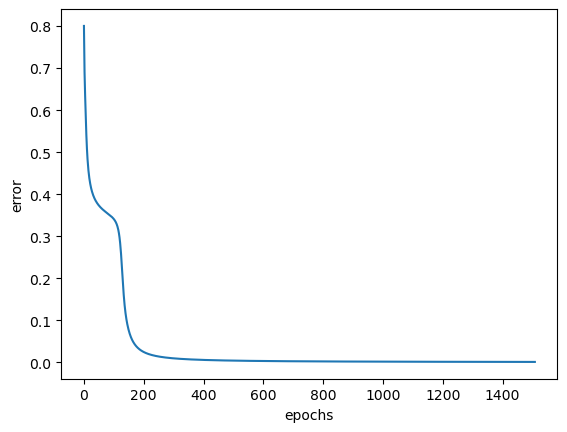

0: produced: [[0.02274021]] wanted [0]
1: produced: [[0.97713684]] wanted [1]
2: produced: [[0.97625794]] wanted [1]
3: produced: [[0.01973848]] wanted [0]


In [ ]:
print('Ran ' + str(end_index) + ' iterations')

# plot it        
plt.plot(error[0:end_index])
plt.ylabel('error')
plt.xlabel('epochs')
plt.show()
        
# what were the values (just do forward pass)  
for i in range(4): 
    
    # forward pass
    layer1_output = np.ones((3, 1))
    layer1_output[0] = np.dot(samples[i,:], n1_w)
    layer1_output[0] = sigmoid(layer1_output[0])
    layer1_output[1] = np.dot(samples[i,:], n2_w)
    layer1_output[1] = sigmoid(layer1_output[1])    
    oo = np.dot(np.transpose(layer1_output), n3_w)
    output = sigmoid(oo) 
    print(str(i) + ": produced: " + str(output) + " wanted " + str(labels[i]))